# Previsão — Copa do Mundo 2026
## Estimativa da Média de Gols por Seleção

**Modelo final:** Ensemble (Regressão Linear + Random Forest + XGBoost) com features **v4**

**48 seleções classificadas — lista oficial:**
- **CONMEBOL (6):** Argentina, Brazil, Colombia, Ecuador, Paraguay, Uruguay
- **UEFA (16):** England, France, Croatia, Norway, Portugal, Germany, Netherlands, Austria, Belgium, Scotland, Spain, Switzerland, Sweden, Turkey, Bosnia and Herzegovina, Czech Republic
- **CONCACAF (6):** United States, Canada, Mexico, Panama, Haiti, Curaçao
- **CAF (10):** Morocco, Senegal, Egypt, Ghana, South Africa, Ivory Coast, Algeria, Tunisia, Cape Verde, DR Congo
- **AFC (9):** Japan, South Korea, Iran, Australia, Saudi Arabia, Iraq, Jordan, Uzbekistan, Qatar
- **OFC (1):** New Zealand

**Erro esperado:** ~0.43–0.46 gols por jogo

## 1. Imports e Carregamento

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../src/features')
from elo import calcular_elo_historico

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

sns.set_theme(style='whitegrid')
np.random.seed(42)

df_features = pd.read_csv('../data/processed/features_completo_v4.csv')
df_raw      = pd.read_csv('../data/raw/results.csv', parse_dates=['date'])

print(f'Dataset treino (v4): {df_features.shape}')
print(f'Dataset bruto: {df_raw.shape}')

Dataset treino (v4): (248, 12)
Dataset bruto: (49287, 9)


## 2. ELO Histórico e Retreino

In [38]:
df = calcular_elo_historico(df_raw, elo_inicial=1000, k_competitivo=40, k_amistoso=20)
print(f'ELO calculado para {len(df)} jogos')

features = [
    'media_gols_marcados_ciclo', 'media_gols_sofridos_ciclo',
    'pct_vitorias_ciclo', 'total_jogos_ciclo',
    'media_gols_marcados_ult15', 'media_gols_sofridos_ult15',
    'pct_vitorias_ult15',
    'elo_medio_adv_ciclo', 'elo_medio_adv_ult15'
]

X_full = df_features[features]
y_full = df_features['media_gols_copa']

lr  = LinearRegression().fit(X_full, y_full)
rf  = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_full, y_full)
xgb = XGBRegressor(n_estimators=100, random_state=42).fit(X_full, y_full)

print(f'Modelos retreinados com {len(X_full)} amostras')

ELO calculado para 49287 jogos
Modelos retreinados com 248 amostras


## 3. Ciclo Preparatório 2026

In [39]:
ciclo_2026 = df[
    (df['date'] >= '2022-12-20') &
    (df['date'] <= '2026-06-10') &
    (df['tournament'] != 'FIFA World Cup')
]

print(f'Total de jogos no ciclo 2026: {len(ciclo_2026)}')
print(f'Período: {ciclo_2026["date"].min().date()} → {ciclo_2026["date"].max().date()}')

Total de jogos no ciclo 2026: 3465
Período: 2022-12-20 → 2026-03-31


## 4. Função de Features v4

In [40]:
def calcular_features_2026_v4(selecao, ciclo, min_jogos=10):
    jogos = ciclo[
        (ciclo['home_team'] == selecao) |
        (ciclo['away_team'] == selecao)
    ].sort_values('date')

    if len(jogos) < min_jogos:
        raise ValueError(f'Apenas {len(jogos)} jogos — mínimo: {min_jogos}')

    gm, gs, vit, elo_adv = [], [], [], []
    for _, row in jogos.iterrows():
        if row['home_team'] == selecao:
            gm.append(row['home_score'])
            gs.append(row['away_score'])
            vit.append(1 if row['home_score'] > row['away_score'] else 0)
            elo_adv.append(row['elo_away_antes'])
        else:
            gm.append(row['away_score'])
            gs.append(row['home_score'])
            vit.append(1 if row['away_score'] > row['home_score'] else 0)
            elo_adv.append(row['elo_home_antes'])

    gm, gs, vit = np.array(gm), np.array(gs), np.array(vit)
    elo_adv = np.array(elo_adv)

    ult15 = jogos.tail(15)
    gm15, gs15, vit15, elo_adv15 = [], [], [], []
    for _, row in ult15.iterrows():
        if row['home_team'] == selecao:
            gm15.append(row['home_score'])
            gs15.append(row['away_score'])
            vit15.append(1 if row['home_score'] > row['away_score'] else 0)
            elo_adv15.append(row['elo_away_antes'])
        else:
            gm15.append(row['away_score'])
            gs15.append(row['home_score'])
            vit15.append(1 if row['away_score'] > row['home_score'] else 0)
            elo_adv15.append(row['elo_home_antes'])

    return {
        'media_gols_marcados_ciclo': gm.mean(),
        'media_gols_sofridos_ciclo': gs.mean(),
        'pct_vitorias_ciclo':        vit.mean(),
        'total_jogos_ciclo':         len(jogos),
        'media_gols_marcados_ult15': np.array(gm15).mean(),
        'media_gols_sofridos_ult15': np.array(gs15).mean(),
        'pct_vitorias_ult15':        np.array(vit15).mean(),
        'elo_medio_adv_ciclo':       elo_adv.mean(),
        'elo_medio_adv_ult15':       np.array(elo_adv15).mean(),
    }

print('Função definida!')

Função definida!


## 5. Seleções Classificadas — Lista Oficial 2026

Lista completa e correta das 48 seleções classificadas para a Copa do Mundo 2026.

**Nota sobre nomes no dataset:** Alguns países aparecem com nomes diferentes no dataset histórico (ex: Turkey em vez de Türkiye, Ivory Coast em vez de Côte d'Ivoire).

In [41]:
# Mapeamento: nome oficial → nome no dataset
selecoes_2026 = {
    # CONMEBOL (6)
    'Argentina':           'CONMEBOL',
    'Brazil':              'CONMEBOL',
    'Colombia':            'CONMEBOL',
    'Ecuador':             'CONMEBOL',
    'Paraguay':            'CONMEBOL',
    'Uruguay':             'CONMEBOL',
    # UEFA (16)
    'England':             'UEFA',
    'France':              'UEFA',
    'Croatia':             'UEFA',
    'Norway':              'UEFA',
    'Portugal':            'UEFA',
    'Germany':             'UEFA',
    'Netherlands':         'UEFA',
    'Austria':             'UEFA',
    'Belgium':             'UEFA',
    'Scotland':            'UEFA',
    'Spain':               'UEFA',
    'Switzerland':         'UEFA',
    'Sweden':              'UEFA',
    'Turkey':              'UEFA',   # Türkiye no dataset
    'Bosnia and Herzegovina': 'UEFA',
    'Czech Republic':      'UEFA',   # Czechia
    # CONCACAF (6)
    'United States':       'CONCACAF',
    'Canada':              'CONCACAF',
    'Mexico':              'CONCACAF',
    'Panama':              'CONCACAF',
    'Haiti':               'CONCACAF',
    'Curaçao':             'CONCACAF',  # Curaçao
    # CAF (10)
    'Morocco':             'CAF',
    'Senegal':             'CAF',
    'Egypt':               'CAF',
    'Ghana':               'CAF',
    'South Africa':        'CAF',
    'Ivory Coast':         'CAF',   # Côte d'Ivoire
    'Algeria':             'CAF',
    'Tunisia':             'CAF',
    'Cape Verde':          'CAF',
    'DR Congo':            'CAF',
    # AFC (9)
    'Japan':               'AFC',
    'South Korea':         'AFC',
    'Iran':                'AFC',
    'Australia':           'AFC',
    'Saudi Arabia':        'AFC',
    'Iraq':                'AFC',
    'Jordan':              'AFC',
    'Uzbekistan':          'AFC',
    'Qatar':               'AFC',
    # OFC (1)
    'New Zealand':         'OFC',
}

print(f'Total de seleções: {len(selecoes_2026)}')
for conf in ['CONMEBOL', 'UEFA', 'CONCACAF', 'CAF', 'AFC', 'OFC']:
    times = [s for s, c in selecoes_2026.items() if c == conf]
    print(f'  {conf} ({len(times)}): {", ".join(times)}')

Total de seleções: 48
  CONMEBOL (6): Argentina, Brazil, Colombia, Ecuador, Paraguay, Uruguay
  UEFA (16): England, France, Croatia, Norway, Portugal, Germany, Netherlands, Austria, Belgium, Scotland, Spain, Switzerland, Sweden, Turkey, Bosnia and Herzegovina, Czech Republic
  CONCACAF (6): United States, Canada, Mexico, Panama, Haiti, Curaçao
  CAF (10): Morocco, Senegal, Egypt, Ghana, South Africa, Ivory Coast, Algeria, Tunisia, Cape Verde, DR Congo
  AFC (9): Japan, South Korea, Iran, Australia, Saudi Arabia, Iraq, Jordan, Uzbekistan, Qatar
  OFC (1): New Zealand


## 6. Calculando Features

In [42]:
dados_2026 = []
sem_dados  = []

for selecao, conf in selecoes_2026.items():
    try:
        resultado = calcular_features_2026_v4(selecao, ciclo_2026, min_jogos=10)
        resultado['selecao']      = selecao
        resultado['confederacao'] = conf
        dados_2026.append(resultado)
    except Exception as e:
        sem_dados.append({'selecao': selecao, 'conf': conf, 'erro': str(e)})

df_2026 = pd.DataFrame(dados_2026)

print(f'Features calculadas: {len(df_2026)} seleções')
if sem_dados:
    print('\nSem dados suficientes:')
    for s in sem_dados:
        print(f"  {s['selecao']} ({s['conf']}): {s['erro']}")

Features calculadas: 48 seleções


## 7. Gerando as Previsões

In [43]:
X_2026 = df_2026[features]

df_2026['pred_lr']    = lr.predict(X_2026)
df_2026['pred_rf']    = rf.predict(X_2026)
df_2026['pred_xgb']   = xgb.predict(X_2026).clip(0)
df_2026['pred_media'] = df_2026[['pred_lr', 'pred_rf', 'pred_xgb']].mean(axis=1)
df_2026['divergencia'] = df_2026[['pred_lr', 'pred_rf', 'pred_xgb']].std(axis=1)

df_2026 = df_2026.sort_values('pred_media', ascending=False).reset_index(drop=True)

print('Top 20 seleções por média de gols prevista:')
print(df_2026[['selecao', 'confederacao', 'pred_lr', 'pred_rf', 'pred_xgb', 'pred_media']]
      .head(20).to_string(index=False))

Top 20 seleções por média de gols prevista:
    selecao confederacao  pred_lr  pred_rf  pred_xgb  pred_media
     Norway         UEFA 1.889281 2.022143  2.077538    1.996321
    England         UEFA 1.755261 1.759762  2.165009    1.893344
Netherlands         UEFA 1.845125 1.984452  1.647255    1.825611
  Argentina     CONMEBOL 1.998648 1.864905  1.540386    1.801313
    Belgium         UEFA 1.842369 1.728619  1.816096    1.795695
    Germany         UEFA 1.740764 1.800286  1.771934    1.770995
   Portugal         UEFA 1.820373 1.689381  1.792786    1.767513
    Croatia         UEFA 1.642932 1.789833  1.817459    1.750075
    Austria         UEFA 1.635047 1.568167  1.992220    1.731811
      Spain         UEFA 2.139320 1.616048  1.378974    1.711447
   Colombia     CONMEBOL 1.936908 1.493429  1.618287    1.682874
New Zealand          OFC 1.657212 1.875810  1.463320    1.665447
     Turkey         UEFA 1.364253 1.524000  1.848213    1.578822
    Ecuador     CONMEBOL 1.594813 1.373762  1.

## 8. Visualização — Top 20

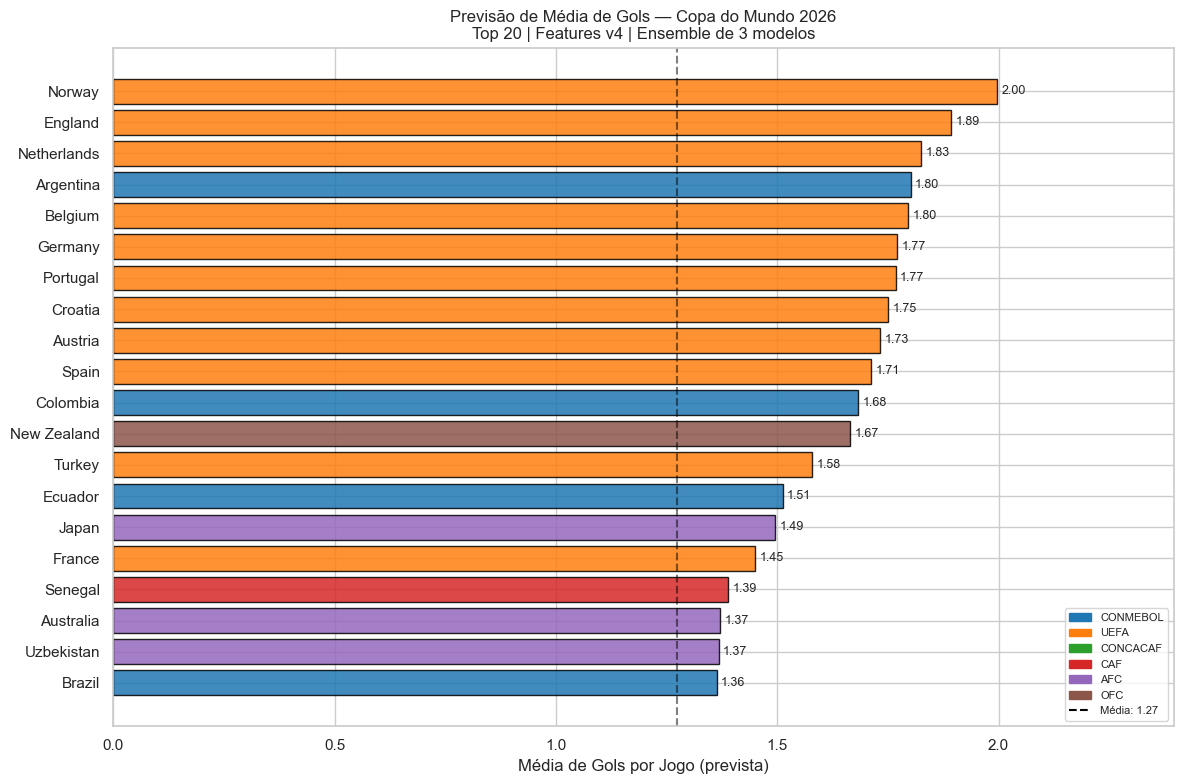

In [44]:
top20 = df_2026.head(20)

cores_conf = {
    'CONMEBOL': '#1f77b4', 'UEFA': '#ff7f0e', 'CONCACAF': '#2ca02c',
    'CAF': '#d62728', 'AFC': '#9467bd', 'OFC': '#8c564b'
}
cores_barras = [cores_conf[c] for c in top20['confederacao'][::-1]]

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(top20['selecao'][::-1], top20['pred_media'][::-1],
               color=cores_barras, edgecolor='black', alpha=0.85)

for bar, val in zip(bars, top20['pred_media'][::-1]):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)

media_geral = df_2026['pred_media'].mean()
ax.axvline(media_geral, color='black', linestyle='--', alpha=0.5,
           label=f'Média geral: {media_geral:.2f}')

# Legenda confederações
from matplotlib.patches import Patch
legend_conf = [Patch(color=c, label=conf) for conf, c in cores_conf.items()]
legend_conf.append(plt.Line2D([0], [0], color='black', linestyle='--', label=f'Média: {media_geral:.2f}'))
ax.legend(handles=legend_conf, loc='lower right', fontsize=8)

ax.set_xlabel('Média de Gols por Jogo (prevista)')
ax.set_title(
    'Previsão de Média de Gols — Copa do Mundo 2026\n'
    'Top 20 | Features v4 | Ensemble de 3 modelos',
    fontsize=12
)
ax.set_xlim(0, top20['pred_media'].max() + 0.4)
plt.tight_layout()
plt.savefig('../article/figures/previsao_2026_top20_v4.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Visualização por Confederação

C:\Users\joaog\AppData\Local\Temp\ipykernel_35312\3179845872.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_2026, x='confederacao', y='pred_media',


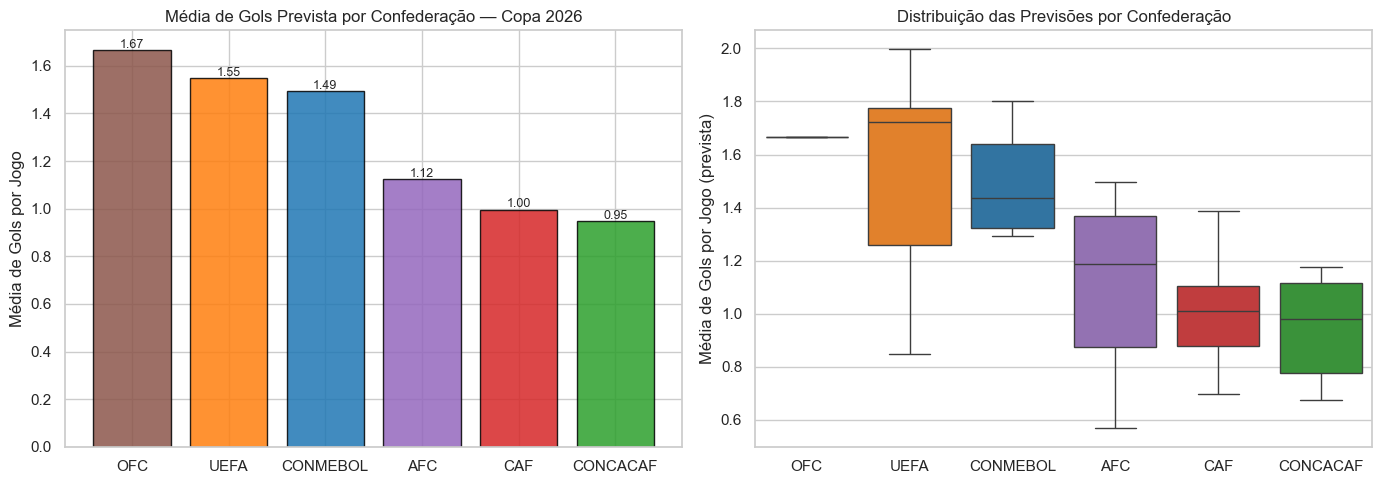

Média prevista por confederação:
confederacao
OFC         1.665
UEFA        1.548
CONMEBOL    1.493
AFC         1.124
CAF         0.996
CONCACAF    0.947


In [45]:
media_conf = df_2026.groupby('confederacao')['pred_media'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cores = [cores_conf[c] for c in media_conf.index]
axes[0].bar(media_conf.index, media_conf.values, color=cores, edgecolor='black', alpha=0.85)
for i, (conf, val) in enumerate(media_conf.items()):
    axes[0].text(i, val + 0.01, f'{val:.2f}', ha='center', fontsize=9)
axes[0].set_title('Média de Gols Prevista por Confederação — Copa 2026')
axes[0].set_ylabel('Média de Gols por Jogo')

order = media_conf.index.tolist()
sns.boxplot(data=df_2026, x='confederacao', y='pred_media',
            order=order, palette=cores_conf, ax=axes[1], legend=False)
axes[1].set_title('Distribuição das Previsões por Confederação')
axes[1].set_ylabel('Média de Gols por Jogo (prevista)')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('../article/figures/previsao_2026_confederacoes_v4.png', dpi=150, bbox_inches='tight')
plt.show()

print('Média prevista por confederação:')
print(media_conf.round(3).to_string())

## 10. Divergência e Confiança

In [46]:
print('Top 10 maior divergência (maior incerteza):')
print(df_2026[['selecao', 'confederacao', 'pred_lr', 'pred_rf', 'pred_xgb', 'pred_media', 'divergencia']]
      .sort_values('divergencia', ascending=False)
      .head(10).to_string(index=False))

print('\nTop 10 menor divergência (maior confiança):')
print(df_2026[['selecao', 'confederacao', 'pred_lr', 'pred_rf', 'pred_xgb', 'pred_media', 'divergencia']]
      .sort_values('divergencia')
      .head(10).to_string(index=False))

Top 10 maior divergência (maior incerteza):
       selecao confederacao  pred_lr  pred_rf  pred_xgb  pred_media  divergencia
        Canada     CONCACAF 1.413031 1.012071  0.621026    1.015376     0.396013
         Spain         UEFA 2.139320 1.616048  1.378974    1.711447     0.389047
        Brazil     CONMEBOL 1.665579 1.397310  1.025693    1.362861     0.321331
Czech Republic         UEFA 1.154094 0.695452  0.692794    0.847447     0.265567
   Switzerland         UEFA 1.539249 1.225786  1.026786    1.263940     0.258353
        Turkey         UEFA 1.364253 1.524000  1.848213    1.578822     0.246593
    Cape Verde          CAF 0.918195 0.733571  0.444454    0.698740     0.238783
     Argentina     CONMEBOL 1.998648 1.864905  1.540386    1.801313     0.235657
       England         UEFA 1.755261 1.759762  2.165009    1.893344     0.235280
        France         UEFA 1.705704 1.400381  1.243792    1.449959     0.234913

Top 10 menor divergência (maior confiança):
     selecao confede

## 11. Salvando as Previsões

In [47]:
cols = [
    'selecao', 'confederacao', 'total_jogos_ciclo',
    'media_gols_marcados_ciclo', 'media_gols_marcados_ult15',
    'elo_medio_adv_ciclo', 'elo_medio_adv_ult15',
    'pred_lr', 'pred_rf', 'pred_xgb', 'pred_media', 'divergencia'
]

df_2026[cols].to_csv('../data/processed/previsao_2026_v4.csv', index=False)
df_2026[cols].to_csv('../article/tables/previsao_2026_v4.csv', index=False)

print('Previsões salvas!')
print(f'Total de seleções: {len(df_2026)}')
print(f'\nResumo (ensemble):')
print(df_2026['pred_media'].describe().round(3))

Previsões salvas!
Total de seleções: 48

Resumo (ensemble):
count    48.000
mean      1.274
std       0.375
min       0.570
25%       1.004
50%       1.256
75%       1.600
max       1.996
Name: pred_media, dtype: float64


## 12. Conclusões

**Sobre as previsões:**
- Lista de seleções baseada na classificação oficial da FIFA (encerrada em 31/03/2026)
- Modelo final: features v4 com ELO médio dos adversários + ensemble de 3 modelos
- O ELO médio dos adversários corrige o viés de seleções com eliminatórias regionais fáceis

**Limitações:**
- Jogos do ciclo disponíveis até março/2026 — alguns jogos finais podem estar ausentes
- Lesões, mudanças de treinador e contexto tático não são capturados
- Erro esperado: ~0.43–0.46 gols por jogo por seleção

**Próximo passo:** Redação do artigo técnico em `article/artigo.md`.